# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/varshitha922/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:** Can search and content signals help identify and rank pages that may deserve a content refresh?

**Decision supported:** Which pages should be reviewed first for a possible content refresh or improvement?


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Data source: FlyRank internship warehouse release on Hugging Face.

Table used: fact_content_daily_performance.

Date window: March 1, 2026 to March 31, 2026.

Unit of analysis: One content item for one client on one report date.

Features used: gsc_impressions, gsc_clicks, and gsc_avg_position.

Excluded: Future-period fields, because they contain information from after the prediction point. Private or identifying fields are also excluded because they are not needed for the analysis.

Data limitations: Clients have different amounts of available history. Some early rows may not have GA4 data. The 90-day query window can also overlap with the performance snapshot window, so the time windows must be aligned before using the data for prediction.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Assumptions: The goal is to rank pages for possible content-refresh review, not to prove that a refresh will cause better performance. Search visibility and content signals are treated as decision-support signals.

Features: gsc_impressions, gsc_clicks, and gsc_avg_position.

Label: Future content performance outcome, measured as the total GSC clicks during the 7 days after the scoring date.

Baseline: A transparent baseline score based on current search visibility. Pages are ranked using their current gsc_impressions value.

Validation design: The model and baseline are evaluated on the same client-holdout split so that pages from the same client are not used in both training and evaluation.

Leakage checks: Future-period fields and future outcome information are excluded from the model inputs. Private or identifying fields are also excluded. The baseline uses only information available at the scoring point.

In [13]:
# Section 3 — Methodology: create the modeling dataset

%pip -q install duckdb

import duckdb
import pandas as pd
from google.colab import userdata

# Get the Hugging Face token from Colab Secrets
token = userdata.get("HF_TOKEN")

if not token:
    raise ValueError(
        "HF_TOKEN is missing. Add it in Colab Secrets and grant notebook access."
    )

# Create DuckDB connection and Hugging Face access
con = duckdb.connect()

con.execute(
    "CREATE OR REPLACE SECRET hf "
    "(TYPE huggingface, TOKEN '" + token + "')"
)

# March 2026 data
march = """
read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
"""

# Scoring date and following 7-day outcome
scoring_date = "2026-03-17"

model_data = con.sql(f"""
WITH scoring AS (
    SELECT
        client_hash_id,
        content_hash_id,
        gsc_impressions,
        gsc_clicks,
        gsc_avg_position
    FROM {march}
    WHERE report_date = DATE '{scoring_date}'
),

future AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_clicks) AS future_7d_clicks
    FROM {march}
    WHERE report_date > DATE '{scoring_date}'
      AND report_date <= DATE '{scoring_date}' + INTERVAL 7 DAY
    GROUP BY client_hash_id, content_hash_id
)

SELECT
    s.client_hash_id,
    s.content_hash_id,
    s.gsc_impressions,
    s.gsc_clicks,
    s.gsc_avg_position,
    COALESCE(f.future_7d_clicks, 0) AS future_7d_clicks
FROM scoring s
LEFT JOIN future f
    ON s.client_hash_id = f.client_hash_id
   AND s.content_hash_id = f.content_hash_id
""").df()

print("Modeling rows:", len(model_data))

display(model_data.head())

print("\nMissing values:")
display(model_data.isna().sum())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Modeling rows: 320048


,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,future_7d_clicks
0,client_3ffa76342f366962,content_5ff0880dc3921364,0,0,NaN,0.0
1,client_3ffa76342f366962,content_bbf2de1067d08bac,0,0,NaN,0.0
2,client_3ffa76342f366962,content_9f68869f6c83127f,0,0,NaN,0.0
3,client_3ffa76342f366962,content_8d54ce0b3b9063a2,0,0,NaN,0.0
4,client_3ffa76342f366962,content_dae0183d0f79442f,0,0,NaN,0.0



Missing values:


,0
client_hash_id,0
content_hash_id,0
gsc_impressions,0
gsc_clicks,0
gsc_avg_position,198334
future_7d_clicks,0


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The final model is compared with a transparent baseline on the same client-holdout test split.

The target is whether a page receives at least one GSC click during the 7 days after the scoring date.

The model uses gsc_impressions, gsc_clicks, and gsc_avg_position. The baseline ranks pages using current gsc_impressions.

Both approaches are evaluated on the same test pages using ROC-AUC. These results support prioritization for review; they do not prove that a content refresh causes better performance.

In [14]:
# Section 4 — Results: compare model with baseline

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Define the target:
# 1 = at least one click in the following 7 days
# 0 = no clicks in the following 7 days
model_data["high_future_performance"] = (
    model_data["future_7d_clicks"] > 0
).astype(int)

# Split by client so the same client is not in both sets
clients = model_data["client_hash_id"].dropna().unique()

rng = np.random.default_rng(42)
rng.shuffle(clients)

split_point = int(len(clients) * 0.8)

train_clients = clients[:split_point]
test_clients = clients[split_point:]

train = model_data[
    model_data["client_hash_id"].isin(train_clients)
].copy()

test = model_data[
    model_data["client_hash_id"].isin(test_clients)
].copy()

print("Training rows:", len(train))
print("Test rows:", len(test))
print("Training clients:", len(train_clients))
print("Test clients:", len(test_clients))

# Features used by the model
features = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position"
]

X_train = train[features]
X_test = test[features]

y_train = train["high_future_performance"]
y_test = test["high_future_performance"]

print("\nTraining target counts:")
print(y_train.value_counts())

print("\nTest target counts:")
print(y_test.value_counts())

# Check that both target classes are present
if y_train.nunique() < 2 or y_test.nunique() < 2:
    raise ValueError(
        "The training or test data has only one target class. "
        "ROC-AUC cannot be calculated."
    )

# Fill missing feature values using training-set medians
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Train the model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_imputed, y_train)

# Model score on test pages
test["model_score"] = model.predict_proba(X_test_imputed)[:, 1]

# Baseline score: current search impressions
test["baseline_score"] = test["gsc_impressions"].fillna(0)

# Evaluate both on the same test pages
model_auc = roc_auc_score(y_test, test["model_score"])
baseline_auc = roc_auc_score(y_test, test["baseline_score"])

performance_table = pd.DataFrame({
    "Method": ["Final model", "Transparent baseline"],
    "ROC-AUC": [model_auc, baseline_auc]
})

print("\nRESULTS")
display(performance_table)

print("Difference (model - baseline):",
      round(model_auc - baseline_auc, 4))

Training rows: 230633
Test rows: 89415
Training clients: 41
Test clients: 11

Training target counts:
high_future_performance
0    209164
1     21469
Name: count, dtype: int64

Test target counts:
high_future_performance
0    71981
1    17434
Name: count, dtype: int64

RESULTS


,Method,ROC-AUC
0,Final model,0.879444
1,Transparent baseline,0.903346


Difference (model - baseline): -0.0239


## 5. Limitations

*What this work cannot claim.*

This work cannot claim that a content refresh will cause better search performance.

The analysis shows associations and is intended for decision support, not causal conclusions.

The data has different amounts of history across clients, and some early rows may not have GA4 data.

The 90-day query window can overlap with the performance snapshot window, so time windows must be aligned before using the data for prediction.

The baseline uses search visibility as a prioritization signal, so a high-priority page may not actually need a content refresh.

The results should therefore be treated as observed or directional evidence for deciding which pages to review first.

In this evaluation, the transparent baseline achieved a higher ROC-AUC than the final model, so the model did not outperform the baseline on the test split.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The action playbook prioritizes pages for review based on the model score and current search signals.

Pages are ranked by the model score to create a review queue. The model score is a prediction signal, not proof that a page needs a content refresh.

Each recommendation includes priority rank, recommended action, reason code, evidence, and what could make it wrong.

These recommendations are decision support. A high-priority page is not automatically proven to need a refresh.


In [15]:
# Section 6 — Ranked recommendations

recommendations = test[
    [
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "baseline_score",
        "gsc_impressions",
        "gsc_clicks",
        "future_7d_clicks"
    ]
].copy()

recommendations = recommendations.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

recommendations["priority_rank"] = (
    recommendations.index + 1
)

recommendations["action"] = np.where(
    recommendations["model_score"] >= 0.5,
    "REVIEW",
    "LOWER_PRIORITY"
)

recommendations["reason_code"] = np.where(
    recommendations["model_score"] >= 0.5,
    "higher_predicted_future_performance",
    "lower_predicted_future_performance"
)

recommendations["evidence"] = (
    "Model score based on current GSC search signals."
)

recommendations["what_would_make_it_wrong"] = (
    "The model may rank a page highly even when a manual review shows no content opportunity."
)

ranked_recommendations = recommendations[
    [
        "priority_rank",
        "action",
        "reason_code",
        "model_score",
        "evidence",
        "what_would_make_it_wrong"
    ]
]

print("TOP 10 RANKED RECOMMENDATIONS")

display(ranked_recommendations.head(10))

TOP 10 RANKED RECOMMENDATIONS


,priority_rank,action,reason_code,model_score,evidence,what_would_make_it_wrong
0,1,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...
1,2,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...
2,3,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...
3,4,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...
4,5,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...
5,6,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...
6,7,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...
7,8,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...
8,9,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...
9,10,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...


In [16]:
print("Model score summary:")
print(test["model_score"].describe())

print("\nNumber of unique model scores:")
print(test["model_score"].nunique())

Model score summary:
count    89415.000000
mean         0.193608
std          0.316785
min          0.000000
25%          0.004310
50%          0.004310
75%          0.252506
max          1.000000
Name: model_score, dtype: float64

Number of unique model scores:
5373


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The paper will embed the key charts and tables generated from the analysis.

Artifacts:

- Baseline versus final model performance table.
- Chart comparing the baseline and final model on the same test split.
- Top 10 ranked recommendations with priority, action, reason code, and supporting evidence.
- Supporting table explaining the role of each feature.

All charts and tables use the actual results generated in the capstone analysis. No illustrative or made-up values are presented as results.

Baseline vs final model performance


,Method,ROC-AUC
0,Final model,0.879444
1,Transparent baseline,0.903346


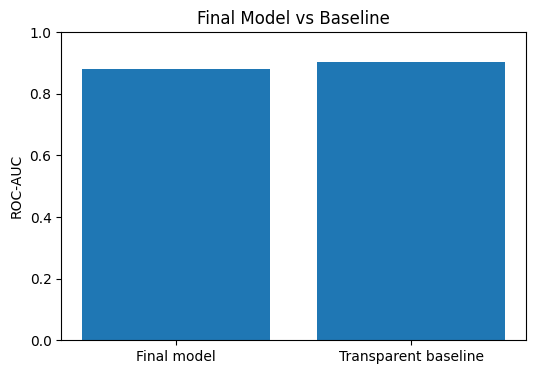

Top 10 ranked recommendations


,priority_rank,action,reason_code,model_score,evidence,what_would_make_it_wrong
0,1,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...
1,2,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...
2,3,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...
3,4,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...
4,5,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...
5,6,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...
6,7,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...
7,8,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...
8,9,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...
9,10,REVIEW,higher_predicted_future_performance,1.0,Model score based on current GSC search signals.,The model may rank a page highly even when a m...


Supporting signal analysis


,Feature,Role
0,gsc_impressions,Search visibility signal
1,gsc_clicks,Search engagement signal
2,gsc_avg_position,Search position signal


In [17]:
# Section 7 — Artifacts for the paper

import pandas as pd
import matplotlib.pyplot as plt

# 1. Performance comparison table
performance_table = pd.DataFrame({
    "Method": ["Final model", "Transparent baseline"],
    "ROC-AUC": [model_auc, baseline_auc]
})

print("Baseline vs final model performance")
display(performance_table)

# 2. Performance comparison chart
plt.figure(figsize=(6, 4))

plt.bar(
    performance_table["Method"],
    performance_table["ROC-AUC"]
)

plt.ylabel("ROC-AUC")
plt.title("Final Model vs Baseline")
plt.ylim(0, 1)
plt.show()

# 3. Top 10 ranked recommendations
print("Top 10 ranked recommendations")
display(ranked_recommendations.head(10))

# 4. Feature-role table
signal_table = pd.DataFrame({
    "Feature": features,
    "Role": [
        "Search visibility signal",
        "Search engagement signal",
        "Search position signal"
    ]
})

print("Supporting signal analysis")
display(signal_table)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
